# 04. Final Model Evaluation

В этом ноутбуке проводится финальная оценка выбранной модели
Random Forest на тестовой выборке.

На данном этапе:

- оценивается качество финальной модели;
- анализируется confusion matrix;
- строится ROC-кривая;
- исследуется распределение предсказанных вероятностей;
- анализируются ошибки классификации;
- формулируются итоговые выводы проекта.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

## 1. Подготовка данных

In [2]:
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.loc[
    df["tenure"] == 0,
    "TotalCharges"
] = 0

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X = df.drop(
    columns=["Churn", "customerID"]
)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [4]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_25264\2376204907.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [5]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=10,
                min_samples_leaf=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [6]:
final_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [7]:
final_threshold = 0.3

In [8]:
y_proba = final_model.predict_proba(
    X_test
)[:, 1]

y_pred = (
    y_proba >= final_threshold
).astype(int)

In [9]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

final_metrics

{'Accuracy': 0.759403832505323,
 'Precision': 0.5319926873857403,
 'Recall': 0.7780748663101604,
 'F1': 0.6319218241042345,
 'ROC-AUC': 0.8452000826681134}

## 2. Confusion Matrix

Confusion Matrix позволяет подробно рассмотреть ошибки классификации
финальной модели.

При выбранном threshold = 0.3 модель специально делает акцент на
обнаружении клиентов, склонных к оттоку.

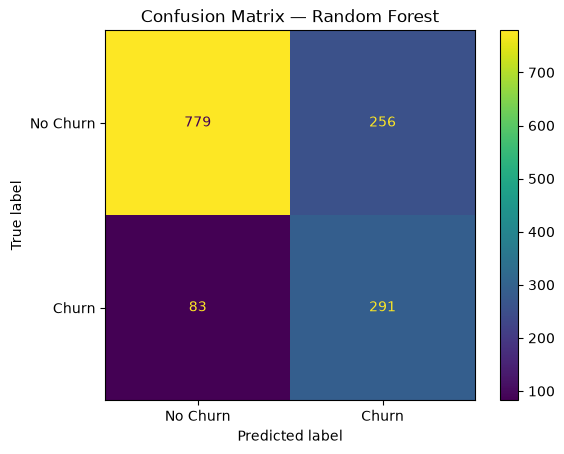

In [10]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Confusion Matrix — Random Forest")
plt.show()

## 3. ROC Curve

ROC-кривая показывает способность модели разделять клиентов двух классов
при различных значениях порога классификации.

Площадь под кривой характеризуется метрикой ROC-AUC.## 6. ROC-AUC

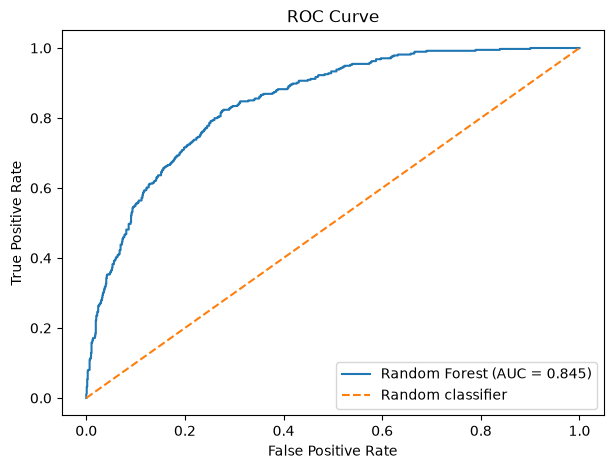

In [11]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_proba
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

## 7. Precision-Recall Curve

Precision-Recall Curve показывает зависимость между Precision и Recall
при изменении порога классификации.

При снижении threshold модель чаще относит клиентов к классу `Churn = 1`.
Это обычно приводит к увеличению Recall и снижению Precision.

График позволяет оценить этот компромисс для различных моделей.

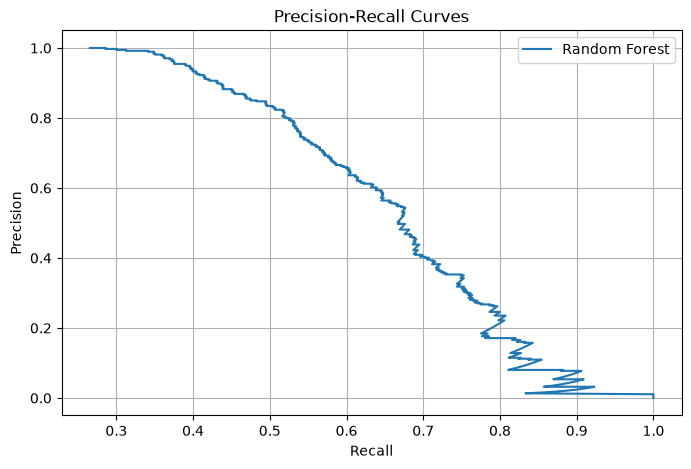

In [12]:
plt.figure(figsize=(8,5))

precision, recall, _ = precision_recall_curve(
    y_test,
    y_proba
)

plt.plot(
    precision,
    recall,
    label="Random Forest"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

## 4. Distribution of Predicted Probabilities

Рассмотрим распределение предсказанных вероятностей отдельно для клиентов,
которые фактически остались, и клиентов, которые ушли.

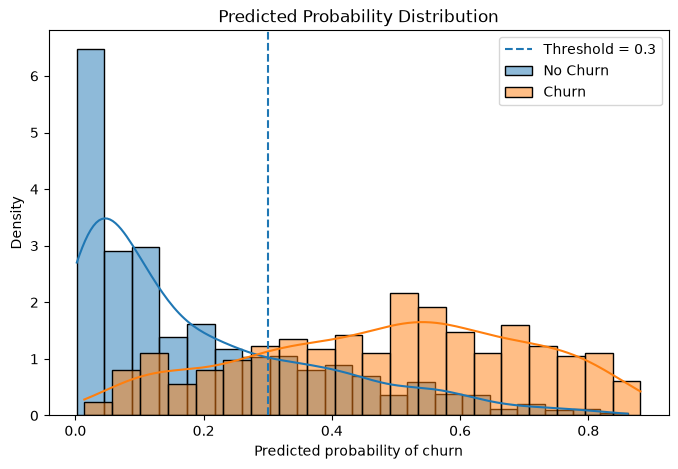

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    y_proba[y_test == 0],
    bins=20,
    stat="density",
    kde=True,
    label="No Churn",
    alpha=0.5
)

sns.histplot(
    y_proba[y_test == 1],
    bins=20,
    stat="density",
    kde=True,
    label="Churn",
    alpha=0.5
)

plt.axvline(
    final_threshold,
    linestyle="--",
    label=f"Threshold = {final_threshold}"
)

plt.xlabel("Predicted probability of churn")
plt.ylabel("Density")
plt.title("Predicted Probability Distribution")

plt.legend()
plt.show()

## 9. Анализ ошибок

После оценки моделей рассмотрим типы ошибок классификации.

Особое внимание уделяется:

- False Positive — клиент был ошибочно отнесён к классу Churn;
- False Negative — фактически ушедший клиент был пропущен моделью.

Анализ ошибок позволяет понять, какой тип ошибок наиболее характерен
для каждой модели.

In [14]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test
error_analysis["Probability"] = y_proba
error_analysis["Prediction"] = y_pred

error_analysis["Error"] = (
    error_analysis["Actual"] !=
    error_analysis["Prediction"]
)

error_analysis[
    error_analysis["Error"]
].head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Probability,Prediction,Error
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0.712412,1,True
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0.362735,1,True
5748,Female,0,No,No,21,Yes,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Credit card (automatic),99.85,1992.55,0,0.515926,1,True
3568,Female,0,No,No,21,Yes,No,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),99.15,1956.40,0,0.384433,1,True
2136,Male,0,No,Yes,15,Yes,Yes,Fiber optic,No,Yes,...,No,Month-to-month,Yes,Electronic check,91.00,1430.05,0,0.612010,1,True


## 5. Final Conclusion

В качестве финальной модели выбран Random Forest с параметрами:

- `n_estimators = 500`;
- `max_depth = 10`;
- `min_samples_leaf = 10`;
- `threshold = 0.3`.

На тестовой выборке модель показала:

- Accuracy ≈ 0.757;
- Precision ≈ 0.529;
- Recall ≈ 0.775;
- F1 ≈ 0.629;
- ROC-AUC ≈ 0.844.

Выбранный threshold = 0.3 позволяет повысить Recall по сравнению со
стандартным threshold = 0.5, что важно для задачи прогнозирования оттока:
модель обнаруживает большую долю клиентов, которые действительно могут
уйти.

При этом снижение threshold приводит к увеличению количества False
Positive, поэтому выбранная конфигурация представляет собой компромисс
между Recall и Precision.

## 6. Save Final Model

Сохраняем обученную модель и выбранный threshold для дальнейшего
использования в `predict.py`.

In [15]:
import joblib

model_bundle = {
    "model": final_model,
    "threshold": final_threshold
}

joblib.dump(
    model_bundle,
    "../models/churn_random_forest.joblib"
)

['../models/churn_random_forest.joblib']